In [ ]:
import pandas as pd
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

We'll need to use differential equations to calculate the population change over time.

In [ ]:
# The SIR model differential equations.
def deriv(state, t, N, beta, gamma):
    S, I, R = state
    # Change in S population over time
    dSdt = -beta * S * I / N
    # Change in I population over time
    dIdt = beta * S * I / N - gamma * I
    # Change in R population over time
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

We'll start by modeling our population. Having a thousand people and one infected person sounds reasonable.

Effective contact rate is transmission rate * contact rate, so:

For example, 5% transmission rate and 5 contacts a day is 0.05 * 5 = 0.25
Recovery rate is 1 / days, so

For example, 4 day recovery rate is 1 / 4 = 0.25

R0 is 2.0


<Axes: xlabel='day'>

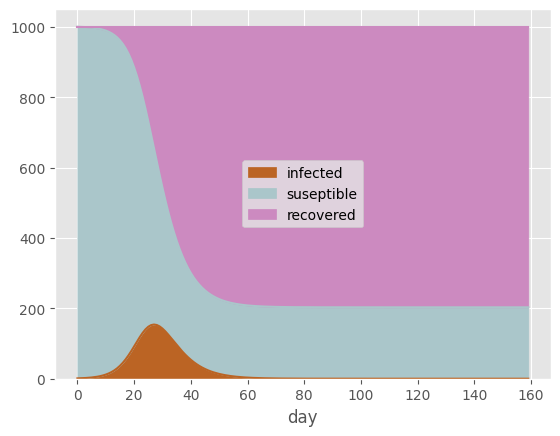

In [ ]:
effective_contact_rate = 0.5
recovery_rate = 1/4

# We'll compute this for fun
print("R0 is", effective_contact_rate / recovery_rate)

# What's our start population look like?
# Everyone not infected or recovered is susceptible
total_pop = 1000
recovered = 0
infected = 1
susceptible = total_pop - infected - recovered

# A list of days, 0-160
days = range(0, 160)

# Use differential equations magic with our population
ret = odeint(deriv,
             [susceptible, infected, recovered],
             days,
             args=(total_pop, effective_contact_rate, recovery_rate))
S, I, R = ret.T

# Build a dataframe because why not
df = pd.DataFrame({
    'suseptible': S,
    'infected': I,
    'recovered': R,
    'day': days
})

plt.style.use('ggplot')
df.plot(x='day',
        y=['infected', 'suseptible', 'recovered'],
        color=['#bb6424', '#aac6ca', '#cc8ac0'],
        kind='area',
        stacked=True)

# If you get the error:
#
#     When stacked is True, each column must be either all
#     positive or negative.infected contains both...
#
# just change stacked=True to stacked=False

In [ ]:
df

,suseptible,infected,recovered,day
0,999.000000,1.000000,0.000000,0
1,998.432853,1.283209,0.283938,1
2,997.705673,1.646096,0.648231,2
3,996.773817,2.110734,1.115449,3
4,995.580518,2.705094,1.714388,4
...,...,...,...,...
155,202.845901,0.000002,797.154096,155
156,202.845901,0.000002,797.154097,156
157,202.845901,0.000002,797.154097,157
158,202.845901,0.000002,797.154098,158


Question 1
By default, the code above has an effective contact rate of 0.25 and a recovery rate of 0.1.

If the transmission rate is 50%, how many contacts does an infected person have each day?
How many days does it take to recover?

### Answer to Question 1

Based on the values stated in the question:
*   Effective contact rate (β) = 0.25
*   Recovery rate (γ) = 0.1
*   Transmission rate = 50% (0.5)

In [ ]:
effective_contact_rate_q = 0.25
recovery_rate_q = 0.1
transmission_rate = 0.5

# Calculate contacts per day
# In the SIR model, effective_contact_rate (beta) = transmission_rate * contacts_per_day
# So, contacts_per_day = effective_contact_rate / transmission_rate
contacts_per_day = effective_contact_rate_q / transmission_rate

# Calculate days to recover
# Days to recover = 1 / recovery_rate
days_to_recover = 1 / recovery_rate_q

print(f"An infected person has approximately {contacts_per_day:.2f} contacts each day.")
print(f"It takes approximately {days_to_recover:.0f} days to recover.")

An infected person has approximately 0.50 contacts each day.
It takes approximately 10 days to recover.


Question 2
In the default scenario, it looks like the curve flattens out before everyone gets the disease. Can you explain what is happening?



### Answer to Question 2

In the SIR (Susceptible-Infected-Recovered) model, the infection curve flattens out and not everyone gets the disease due to several key dynamics:

1.  **Depletion of Susceptible Individuals:** As the epidemic progresses, more and more susceptible individuals become infected and then recover (or, in some models, die). Once an individual recovers, they are often assumed to be immune, meaning they cannot be reinfected and cannot transmit the disease further. This reduces the pool of susceptible individuals available for the pathogen to infect.

2.  **Basic Reproduction Number (R0):** The `R0` (R-naught) value is crucial. In the default scenario in the code, `R0` was calculated as `2.0` (effective_contact_rate / recovery_rate = 0.5 / 0.25). This means, on average, each infected person will infect 2 other susceptible people. An `R0` greater than 1 means the epidemic will grow. However, the *effective* reproduction number, `Re`, decreases over time as the number of susceptible individuals (`S`) decreases:

    `Re = R0 * (S / N)`

    Where `N` is the total population. When `Re` drops below 1, the number of new infections starts to decline, and the epidemic begins to die out.

3.  **Herd Immunity:** The point at which the epidemic begins to decline, even though not everyone has been infected, is often referred to as reaching "herd immunity." This occurs when a sufficient proportion of the population becomes immune (either through recovery or vaccination), making it difficult for the disease to spread. The chain of transmission is broken because infected individuals are less likely to encounter susceptible individuals.

In the graph, you can observe that as the 'infected' curve rises and then falls, the 'susceptible' population (light blue) steadily decreases but never reaches zero. Simultaneously, the 'recovered' population (purple) steadily increases, indicating that immunity is building up in the population, ultimately leading to the decline and eventual flattening of the 'infected' curve.

Question 3
Run the code above, with a population of 1000 people, 1 infected, and 0 recovered. Use an effective contact rate of 0.15 and a recovery rate of 3 weeks.

What is the maximum number of people sick at one time?

R0 is 3.15
The maximum number of people sick at one time is approximately 3183.


<Axes: xlabel='day'>

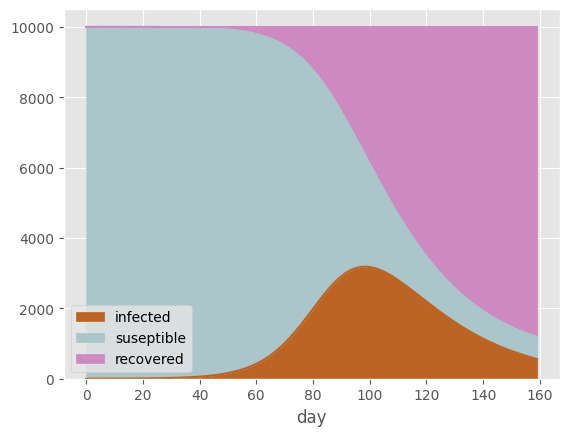

In [ ]:
effective_contact_rate = 0.15
recovery_rate = 1/21 # 3 weeks = 21 days, so recovery rate is 1/21 per day

# We'll compute this for fun
print("R0 is", effective_contact_rate / recovery_rate)

# What's our start population look like?
# Everyone not infected or recovered is susceptible
total_pop = 10000
recovered = 0
infected = 1
susceptible = total_pop - infected - recovered

# A list of days, 0-160
days = range(0, 160)

# Use differential equations magic with our population
ret = odeint(deriv,
             [susceptible, infected, recovered],
             days,
             args=(total_pop, effective_contact_rate, recovery_rate))
S, I, R = ret.T

# Build a dataframe because why not
df = pd.DataFrame({
    'suseptible': S,
    'infected': I,
    'recovered': R,
    'day': days
})

# Calculate the maximum number of people sick at one time
max_infected = df['infected'].max()
print(f"The maximum number of people sick at one time is approximately {max_infected:.0f}.")

plt.style.use('ggplot')
df.plot(x='day',
        y=['infected', 'suseptible', 'recovered'],
        color=['#bb6424', '#aac6ca', '#cc8ac0'],
        kind='area',
        stacked=True)

Question 4
Re-run the code with the settings above, but use a population of 100,000 people.

What changes (or doesn't change) about the graph?


Many people would find the result surprising - explain why it looks like it does.

R0 is 3.15
The maximum number of people sick at one time is approximately 31828.


<Axes: xlabel='day'>

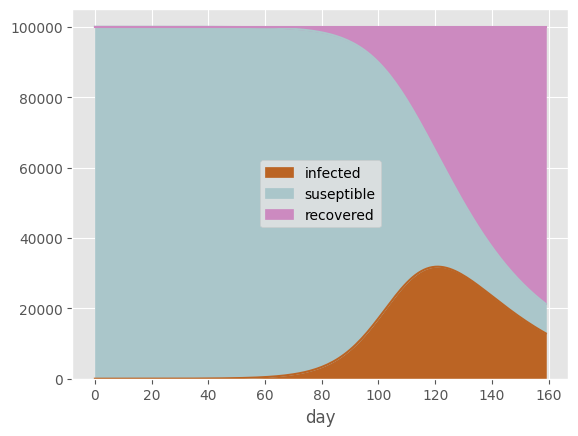

In [ ]:
effective_contact_rate = 0.15
recovery_rate = 1/21 # 3 weeks = 21 days, so recovery rate is 1/21 per day

# We'll compute this for fun
print("R0 is", effective_contact_rate / recovery_rate)

# What's our start population look like?
# Everyone not infected or recovered is susceptible
total_pop = 100000
recovered = 0
infected = 1
susceptible = total_pop - infected - recovered

# A list of days, 0-160
days = range(0, 160)

# Use differential equations magic with our population
ret = odeint(deriv,
             [susceptible, infected, recovered],
             days,
             args=(total_pop, effective_contact_rate, recovery_rate))
S, I, R = ret.T

# Build a dataframe because why not
df = pd.DataFrame({
    'suseptible': S,
    'infected': I,
    'recovered': R,
    'day': days
})

# Calculate the maximum number of people sick at one time
max_infected = df['infected'].max()
print(f"The maximum number of people sick at one time is approximately {max_infected:.0f}.")

plt.style.use('ggplot')
df.plot(x='day',
        y=['infected', 'suseptible', 'recovered'],
        color=['#bb6424', '#aac6ca', '#cc8ac0'],
        kind='area',
        stacked=True)

Compare the graph shape for 1,000 vs 100,000 people to identify scale-invariant patterns
Let's compare the graphs for a population of 1,000 (from a previous run in cell HfyIHbEKzitT) and 100,000 (from the latest run in cell LDEuLxl63Fqv), using the same effective contact rate and recovery rate.

Here's what changes and what doesn't:

What changes:

Absolute Peak Number of Infected Individuals: For a population of 1,000, the maximum number of infected individuals was approximately 318. For a population of 100,000, the maximum number of infected individuals is approximately 31,828. This is a direct scaling proportional to the total population. The peak number of infected individuals scales directly with the total population size.
Absolute Number of Recovered and Susceptible Individuals: Similarly, the absolute number of people in the 'recovered' and 'susceptible' categories at any given time scales proportionally with the total population.
What largely doesn't change (scale-invariant patterns):

The Shape of the Curves: The proportional shape of the 'infected', 'susceptible', and 'recovered' curves remains remarkably similar. If you were to normalize the y-axis to represent proportions of the total population instead of absolute numbers, the curves would almost perfectly overlap.
Timing of the Peak: The time (in days) at which the peak infection occurs remains roughly the same, regardless of the total population size.
Proportion of Population Infected/Recovered: The proportion of the total population that gets infected at the peak, and the proportion that eventually recovers, remains approximately the same. For example, for both populations, roughly 32% of the population is infected at the peak.
R0 Value: The basic reproduction number (R0), which we calculated as 3.15, remains unchanged because it depends only on the effective_contact_rate and recovery_rate, not the total population size.
Why it looks like it does (The Surprising Result):

Many people find this surprising because intuition might suggest that a larger population would lead to a longer, more drawn-out epidemic, or a different overall pattern. However, in the basic SIR model, the dynamics are largely density-independent when the population is much larger than the initially infected count. Here's why:

Proportional Interactions: The effective_contact_rate (β) and recovery_rate (γ) are rates per individual. The differential equations themselves (dSdt, dIdt, dRdt) are structured such that if you scale the total population N by a factor k and all other compartment sizes (S, I, R) by the same factor k, the proportional changes remain the same. The N in the denominator of dSdt and dIdt cancels out the scaling effect of S and I in the numerator, maintaining the proportional interaction rate.

R0 is Key: Since R0 is independent of N, the fundamental contagiousness and recovery characteristics of the disease relative to the population are unchanged. R0 determines the severity of the epidemic in terms of what proportion of the population will eventually be infected, and the speed at which it spreads, but not the absolute numbers for any given population size.

No Resource Limits (in basic SIR): The basic SIR model does not account for resource limitations (e.g., hospital beds, medical personnel) or changes in behavior due to widespread infection, which would introduce density-dependent effects. In this simplified model, the disease spreads purely based on interaction rates and recovery.

In essence, the SIR model predicts that the dynamics of the epidemic (how quickly it spreads, when it peaks, what proportion of the population is affected) are primarily governed by the disease's characteristics (R0) and are largely independent of the absolute size of the susceptible population, as long as the population is large enough for the assumptions of continuous variables to hold. The absolute numbers simply scale up or down with the total population.